In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [ ]:


df = pd.read_csv('../data/gurgaon_properties_missing_value_imputation.csv')


df.head()

TypeError: Cannot convert numpy.ndarray to numpy.ndarray

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = df.drop(columns=['society','price_per_sqft'])

<h2> luxury_score </h2>

<Axes: xlabel='luxury_score'>

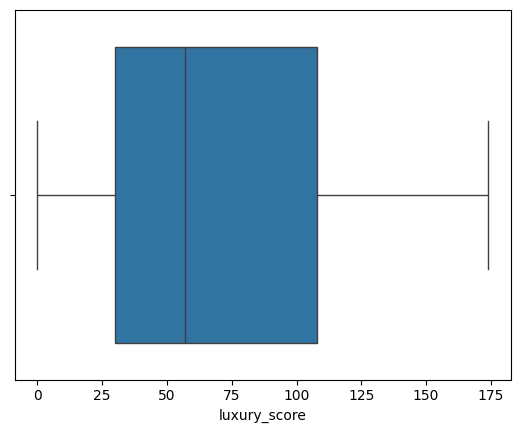

In [ ]:
sns.boxplot(data = df, x = 'luxury_score')

In [ ]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None

In [ ]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [ ]:

train_df.head()

,property_type,price,sector,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,1.30,sector 79,2,2,3,3.0,New Property,1423.0,1,0,0,0,0,1,49.0,Low
1,flat,1.63,sector 70,3,5,3,12.0,Relatively New,1528.0,0,1,0,0,0,1,43.0,Low
2,flat,7.40,sector 53,4,4,3,21.0,Under Construction,2477.0,0,0,0,0,0,1,35.0,Low
3,flat,0.65,sector 92,3,2,3,6.0,Relatively New,1240.0,0,0,0,0,0,1,49.0,Low
4,flat,0.60,sector 71,2,2,1,5.0,Relatively New,557.0,0,0,0,1,0,1,59.0,Medium


<h2> floorNum </h2>

<Axes: xlabel='floorNum'>

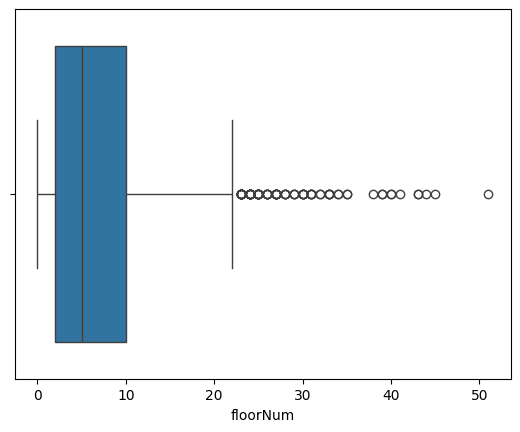

In [ ]:
sns.boxplot(data = df, x = 'floorNum')

In [ ]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [ ]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [ ]:
train_df.head()

,property_type,price,sector,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,1.30,sector 79,2,2,3,3.0,New Property,1423.0,1,0,0,0,0,1,49.0,Low,Mid Floor
1,flat,1.63,sector 70,3,5,3,12.0,Relatively New,1528.0,0,1,0,0,0,1,43.0,Low,High Floor
2,flat,7.40,sector 53,4,4,3,21.0,Under Construction,2477.0,0,0,0,0,0,1,35.0,Low,High Floor
3,flat,0.65,sector 92,3,2,3,6.0,Relatively New,1240.0,0,0,0,0,0,1,49.0,Low,Mid Floor
4,flat,0.60,sector 71,2,2,1,5.0,Relatively New,557.0,0,0,0,1,0,1,59.0,Medium,Mid Floor


In [ ]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [ ]:
train_df.head()

,property_type,price,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,1.30,sector 79,2,2,3,New Property,1423.0,1,0,0,0,0,1,Low,Mid Floor
1,flat,1.63,sector 70,3,5,3,Relatively New,1528.0,0,1,0,0,0,1,Low,High Floor
2,flat,7.40,sector 53,4,4,3,Under Construction,2477.0,0,0,0,0,0,1,Low,High Floor
3,flat,0.65,sector 92,3,2,3,Relatively New,1240.0,0,0,0,0,0,1,Low,Mid Floor
4,flat,0.60,sector 71,2,2,1,Relatively New,557.0,0,0,0,1,0,1,Medium,Mid Floor


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['a block sector 43', 'b block sector 43', 'bhondsi', 'bissar',
       'block a sector 4', 'c block sector 43', 'dwarka expressway',
       'farukhnagar', 'golf course ext road', 'golf course road',
       'imt manesar', 'manesar', 'mehrauli  road', 'mianwali colony',
       'mohan nagar', 'nars', 'new', 'new sector 23',
       'new sector 23 phase 1', 'new sector 23 phase 2',
       'saraswati vihar', 'sector 1', 'sector 1 imt manesar',
       'sector 102', 'sector 103', 'sector 104', 'sector 104 1',
       'sector 105', 'sector 106', 'sector 107', 'sector 108',
       'sector 109', 'sector 10a', 'sector 11', 'sector 110',
       'sector 110 a', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 12a', 'sector 13', 'sector 14', 'sector 15',
       'sector 15 part 1', 'sector 15 part 2', 'sector 17', 'sector 17a',
       'sector 17b', 'sector 1a imt manesar', 'sector 2', 'sector 21',
       'sector 22', 'sector 23', 'sec

<h2> Technique 1 - Correlation Analysis</h2>

<Axes: >

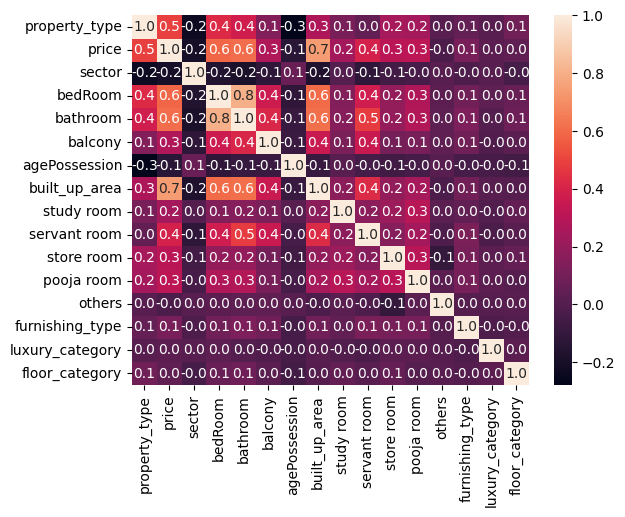

In [ ]:
 sns.heatmap(data_label_encoded.corr(), annot = True, fmt= '.1f')

In [ ]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,price,1.000000
1,sector,-0.199624
2,bedRoom,0.589514
3,bathroom,0.609448
4,balcony,0.273174
5,agePossession,-0.134576
6,built_up_area,0.742798
7,study room,0.240833
8,servant room,0.392619
9,store room,0.306349


<h2> Technique 2 - Random Forest Feature Importance</h2>

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.645328
0,property_type,0.099840
1,sector,0.096886
2,bedRoom,0.026539
3,bathroom,0.026376
8,servant room,0.023115
5,agePossession,0.016268
4,balcony,0.013426
9,store room,0.011948
12,furnishing_type,0.010945


<h2> Technique 3 - Gradient Boosting Feature importances </h2>

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.672159
1,sector,0.098396
0,property_type,0.095504
2,bedRoom,0.039329
3,bathroom,0.035739
8,servant room,0.028485
9,store room,0.014065
5,agePossession,0.005379
4,balcony,0.003502
13,luxury_category,0.002648


<h2> Technique 4 - Permutation Importance </h2>

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.713543
0,property_type,0.175388
1,sector,0.124598
8,servant room,0.013554
2,bedRoom,0.007479
3,bathroom,0.005765
4,balcony,0.005444
9,store room,0.002672
14,floor_category,0.001859
10,pooja room,0.001812


<h2> Technique 5 - LASSO </h2>

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.461077
0,property_type,0.682712
3,bathroom,0.315538
9,store room,0.210632
8,servant room,0.185264
7,study room,0.174905
10,pooja room,0.074326
12,furnishing_type,0.043752
2,bedRoom,0.038429
13,luxury_category,0.025875


<h2> Technique 6 - RFE </h2>

In [ ]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.642500
0,property_type,0.104938
1,sector,0.096345
3,bathroom,0.026813
2,bedRoom,0.026525
8,servant room,0.024394
5,agePossession,0.016031
4,balcony,0.013590
12,furnishing_type,0.010751
13,luxury_category,0.009085


<h2> Technique 7 - Linear Regression Weights </h2>

In [ ]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.463799
0,property_type,0.689097
3,bathroom,0.319985
9,store room,0.213882
8,servant room,0.193881
7,study room,0.182894
10,pooja room,0.075913
12,furnishing_type,0.052504
2,bedRoom,0.041192
13,luxury_category,0.036231


In [ ]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').set_index('feature')

In [ ]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,,
sector,-0.199624,0.096886,0.098396,0.124598,-0.033979,0.096345,-0.042470
bedRoom,0.589514,0.026539,0.039329,0.007479,0.038429,0.026525,0.041192
bathroom,0.609448,0.026376,0.035739,0.005765,0.315538,0.026813,0.319985
balcony,0.273174,0.013426,0.003502,0.005444,-0.136305,0.013590,-0.156356
agePossession,-0.134576,0.016268,0.005379,-0.000362,0.000000,0.016031,0.003647
built_up_area,0.742798,0.645328,0.672159,0.713543,1.461077,0.642500,1.463799
study room,0.240833,0.006112,0.000657,0.000169,0.174905,0.007477,0.182894
servant room,0.392619,0.023115,0.028485,0.013554,0.185264,0.024394,0.193881
store room,0.306349,0.011948,0.014065,0.002672,0.210632,0.007506,0.213882


In [ ]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [ ]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)

,0
feature,
built_up_area,0.751673
sector,0.117197
bedRoom,0.027821
bathroom,0.026367
servant room,0.025043
agePossession,0.010377
store room,0.010078
balcony,0.010073
furnishing_type,0.005321


In [ ]:
# to drop pooja room, study room, others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,119.0,2,2,3.0,1.0,1423.0,1,0,0,0,0,1,1.0,2.0
1,0.0,110.0,3,5,3.0,3.0,1528.0,0,1,0,0,0,1,1.0,0.0
2,0.0,90.0,4,4,3.0,4.0,2477.0,0,0,0,0,0,1,1.0,0.0
3,0.0,137.0,3,2,3.0,3.0,1240.0,0,0,0,0,0,1,1.0,2.0
4,0.0,112.0,2,2,1.0,3.0,557.0,0,0,0,1,0,1,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3734,0.0,122.0,3,2,4.0,3.0,1353.0,0,0,0,0,1,1,1.0,2.0
3735,1.0,134.0,2,2,1.0,0.0,558.0,0,0,0,0,0,1,1.0,1.0
3736,0.0,99.0,3,4,4.0,4.0,2250.0,0,1,0,0,0,1,1.0,0.0
3737,1.0,82.0,3,8,2.0,3.0,1836.0,1,0,0,1,0,2,1.0,2.0


In [ ]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.7965317658005374)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.7972277955209984)

In [ ]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [ ]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [ ]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,119.0,2,2,3.0,1.0,1423.0,0,0,1,1.0,2.0,1.30
1,0.0,110.0,3,5,3.0,3.0,1528.0,1,0,1,1.0,0.0,1.63
2,0.0,90.0,4,4,3.0,4.0,2477.0,0,0,1,1.0,0.0,7.40
3,0.0,137.0,3,2,3.0,3.0,1240.0,0,0,1,1.0,2.0,0.65
4,0.0,112.0,2,2,1.0,3.0,557.0,0,0,1,2.0,2.0,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3734,0.0,122.0,3,2,4.0,3.0,1353.0,0,0,1,1.0,2.0,1.45
3735,1.0,134.0,2,2,1.0,0.0,558.0,0,0,1,1.0,1.0,0.60
3736,0.0,99.0,3,4,4.0,4.0,2250.0,1,0,1,1.0,0.0,3.87
3737,1.0,82.0,3,8,2.0,3.0,1836.0,0,0,2,1.0,2.0,4.35


In [ ]:
!ls

appartments.csv
Data_preprocessing_flats.ipynb
Data_preprocessing_houses.ipynb
data_preprocessing_hyderabad.ipynb
eda_multivariate_analysis.ipynb
eda_pandas_profiling.ipynb
eda-univariate_analysis.ipynb
feature-engineering.ipynb
featuring-selection.ipynb
flats_cleaned.csv
flats.csv
gurgaon_properties_cleaned_v1.csv
gurgaon_properties_cleaned_v2.csv
gurgaon_properties_missing_value_imputation.csv
gurgaon_properties_outliers_treatment.csv
gurgaon_properties_post_feature_selection.csv
gurgoan_properties.csv
Handling_missing_values.ipynb
houses_cleaned.csv
houses.csv
hyderabad.csv
merge-flats-houses.ipynb
Outliers.ipynb
output_report.html
